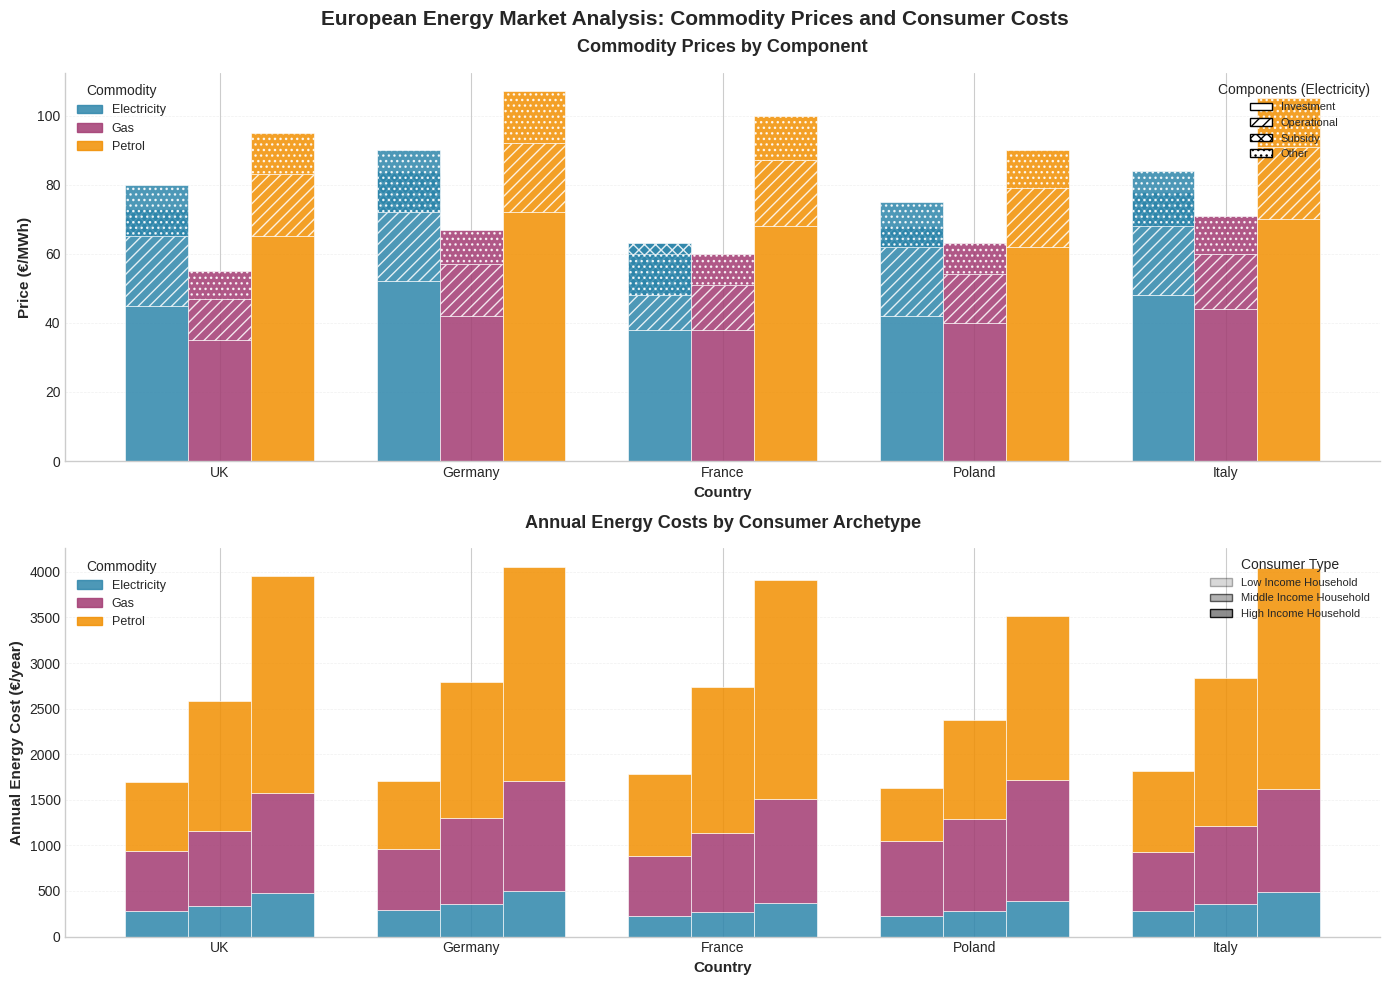


SUMMARY STATISTICS

UK:
  Total Commodity Prices (€/MWh):
    Electricity: €80.00
    Gas: €55.00
    Petrol: €95.00

  Annual Consumer Costs (€/year):
    Low Income Household: €1700.00
    Middle Income Household: €2586.00
    High Income Household: €3955.00

Germany:
  Total Commodity Prices (€/MWh):
    Electricity: €90.00
    Gas: €67.00
    Petrol: €107.00

  Annual Consumer Costs (€/year):
    Low Income Household: €1707.00
    Middle Income Household: €2796.00
    High Income Household: €4055.00

France:
  Total Commodity Prices (€/MWh):
    Electricity: €60.00
    Gas: €60.00
    Petrol: €100.00

  Annual Consumer Costs (€/year):
    Low Income Household: €1788.00
    Middle Income Household: €2740.00
    High Income Household: €3912.00

Poland:
  Total Commodity Prices (€/MWh):
    Electricity: €75.00
    Gas: €63.00
    Petrol: €90.00

  Annual Consumer Costs (€/year):
    Low Income Household: €1629.00
    Middle Income Household: €2373.00
    High Income Household: €3513.

In [2]:
"""
European Energy Cost Visualization
Dual barplot analysis of commodity prices and consumer energy costs
"""

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import matplotlib.patches as mpatches

# ============================================================================
# DATA CONFIGURATION
# ============================================================================

# Commodity price components (Euro/MWh_delivered)
COMMODITY_PRICES = {
    'UK': {
        'electricity': {'investment': 45, 'operational': 28, 'subsidy': -8, 'other': 15},
        'gas': {'VOM': 35, 'FOM': 12, 'other': 8},
        'petrol': {'VOM': 65, 'FOM': 18, 'other': 12}
    },
    'Germany': {
        'electricity': {'investment': 52, 'operational': 32, 'subsidy': -12, 'other': 18},
        'gas': {'VOM': 42, 'FOM': 15, 'other': 10},
        'petrol': {'VOM': 72, 'FOM': 20, 'other': 15}
    },
    'France': {
        'electricity': {'investment': 38, 'operational': 25, 'subsidy': -15, 'other': 12},
        'gas': {'VOM': 38, 'FOM': 13, 'other': 9},
        'petrol': {'VOM': 68, 'FOM': 19, 'other': 13}
    },
    'Poland': {
        'electricity': {'investment': 42, 'operational': 26, 'subsidy': -6, 'other': 13},
        'gas': {'VOM': 40, 'FOM': 14, 'other': 9},
        'petrol': {'VOM': 62, 'FOM': 17, 'other': 11}
    },
    'Italy': {
        'electricity': {'investment': 48, 'operational': 30, 'subsidy': -10, 'other': 16},
        'gas': {'VOM': 44, 'FOM': 16, 'other': 11},
        'petrol': {'VOM': 70, 'FOM': 21, 'other': 14}
    }
}

# Consumer archetypes - energy consumption per commodity (MWh/year)
CONSUMER_ARCHETYPES = {
    'UK': {
        'Low Income Household': {'electricity': 3.5, 'gas': 12.0, 'petrol': 8.0},
        'Middle Income Household': {'electricity': 4.2, 'gas': 15.0, 'petrol': 15.0},
        'High Income Household': {'electricity': 6.0, 'gas': 20.0, 'petrol': 25.0}
    },
    'Germany': {
        'Low Income Household': {'electricity': 3.2, 'gas': 10.0, 'petrol': 7.0},
        'Middle Income Household': {'electricity': 4.0, 'gas': 14.0, 'petrol': 14.0},
        'High Income Household': {'electricity': 5.5, 'gas': 18.0, 'petrol': 22.0}
    },
    'France': {
        'Low Income Household': {'electricity': 3.8, 'gas': 11.0, 'petrol': 9.0},
        'Middle Income Household': {'electricity': 4.5, 'gas': 14.5, 'petrol': 16.0},
        'High Income Household': {'electricity': 6.2, 'gas': 19.0, 'petrol': 24.0}
    },
    'Poland': {
        'Low Income Household': {'electricity': 3.0, 'gas': 13.0, 'petrol': 6.5},
        'Middle Income Household': {'electricity': 3.8, 'gas': 16.0, 'petrol': 12.0},
        'High Income Household': {'electricity': 5.2, 'gas': 21.0, 'petrol': 20.0}
    },
    'Italy': {
        'Low Income Household': {'electricity': 3.4, 'gas': 9.0, 'petrol': 8.5},
        'Middle Income Household': {'electricity': 4.3, 'gas': 12.0, 'petrol': 15.5},
        'High Income Household': {'electricity': 5.8, 'gas': 16.0, 'petrol': 23.0}
    }
}

# ============================================================================
# VISUALIZATION CONFIGURATION
# ============================================================================

# Color scheme
COMMODITY_COLORS = {
    'electricity': '#2E86AB',  # Blue
    'gas': '#A23B72',          # Purple
    'petrol': '#F18F01'        # Orange
}

# Hatch patterns for components
COMPONENT_HATCHES = {
    'electricity': ['', '///', 'xxx', '...'],
    'gas': ['', '///', '...'],
    'petrol': ['', '///', '...']
}

COUNTRIES = ['UK', 'Germany', 'France', 'Poland', 'Italy']
COMMODITIES = ['electricity', 'gas', 'petrol']

# ============================================================================
# HELPER FUNCTIONS
# ============================================================================

def calculate_total_commodity_price(country, commodity):
    """Calculate total price for a commodity in a country"""
    return sum(COMMODITY_PRICES[country][commodity].values())

def calculate_consumer_costs(country, archetype):
    """Calculate total annual costs for a consumer archetype"""
    costs = {}
    consumption = CONSUMER_ARCHETYPES[country][archetype]
    
    for commodity in COMMODITIES:
        total_price = calculate_total_commodity_price(country, commodity)
        costs[commodity] = consumption[commodity] * total_price
    
    costs['total'] = sum(costs.values())
    return costs

# ============================================================================
# PLOTTING FUNCTIONS
# ============================================================================

def plot_commodity_prices(ax):
    """Plot stacked bar chart of commodity prices"""
    
    bar_width = 0.25
    x = np.arange(len(COUNTRIES))
    
    for i, commodity in enumerate(COMMODITIES):
        offset = (i - 1) * bar_width
        
        for country_idx, country in enumerate(COUNTRIES):
            components = COMMODITY_PRICES[country][commodity]
            component_names = list(components.keys())
            component_values = list(components.values())
            
            bottom = 0
            for comp_idx, (comp_name, value) in enumerate(zip(component_names, component_values)):
                hatch = COMPONENT_HATCHES[commodity][comp_idx]
                
                ax.bar(country_idx + offset, value, bar_width,
                      bottom=bottom,
                      color=COMMODITY_COLORS[commodity],
                      edgecolor='white',
                      linewidth=0.5,
                      hatch=hatch,
                      alpha=0.85)
                bottom += value
    
    # Formatting
    ax.set_ylabel('Price (€/MWh)', fontsize=11, fontweight='bold')
    ax.set_xlabel('Country', fontsize=11, fontweight='bold')
    ax.set_title('Commodity Prices by Component', fontsize=13, fontweight='bold', pad=15)
    ax.set_xticks(x)
    ax.set_xticklabels(COUNTRIES, fontsize=10)
    ax.grid(axis='y', alpha=0.3, linestyle='--', linewidth=0.5)
    ax.set_axisbelow(True)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    # Create legend
    commodity_patches = [mpatches.Patch(color=COMMODITY_COLORS[c], label=c.capitalize(), alpha=0.85) 
                        for c in COMMODITIES]
    
    # Create hatch legend for electricity components
    elec_components = list(COMMODITY_PRICES['UK']['electricity'].keys())
    hatch_patches = [mpatches.Patch(facecolor='white', edgecolor='black', 
                                   hatch=COMPONENT_HATCHES['electricity'][i], 
                                   label=comp.capitalize()) 
                    for i, comp in enumerate(elec_components)]
    
    # Combined legend
    first_legend = ax.legend(handles=commodity_patches, loc='upper left', 
                            title='Commodity', framealpha=0.95, fontsize=9)
    ax.add_artist(first_legend)
    ax.legend(handles=hatch_patches, loc='upper right', 
             title='Components (Electricity)', framealpha=0.95, fontsize=8)

def plot_consumer_costs(ax):
    """Plot stacked bar chart of consumer energy costs"""
    
    archetypes = ['Low Income Household', 'Middle Income Household', 'High Income Household']
    bar_width = 0.25
    x = np.arange(len(COUNTRIES))
    
    for arch_idx, archetype in enumerate(archetypes):
        offset = (arch_idx - 1) * bar_width
        
        for country_idx, country in enumerate(COUNTRIES):
            costs = calculate_consumer_costs(country, archetype)
            
            bottom = 0
            for commodity in COMMODITIES:
                ax.bar(country_idx + offset, costs[commodity], bar_width,
                      bottom=bottom,
                      color=COMMODITY_COLORS[commodity],
                      edgecolor='white',
                      linewidth=0.5,
                      alpha=0.85,
                      label=commodity.capitalize() if country_idx == 0 and arch_idx == 0 else "")
                bottom += costs[commodity]
    
    # Formatting
    ax.set_ylabel('Annual Energy Cost (€/year)', fontsize=11, fontweight='bold')
    ax.set_xlabel('Country', fontsize=11, fontweight='bold')
    ax.set_title('Annual Energy Costs by Consumer Archetype', fontsize=13, fontweight='bold', pad=15)
    ax.set_xticks(x)
    ax.set_xticklabels(COUNTRIES, fontsize=10)
    ax.grid(axis='y', alpha=0.3, linestyle='--', linewidth=0.5)
    ax.set_axisbelow(True)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    # Create legends
    commodity_patches = [mpatches.Patch(color=COMMODITY_COLORS[c], label=c.capitalize(), alpha=0.85) 
                        for c in COMMODITIES]
    
    archetype_patches = [mpatches.Patch(facecolor='gray', edgecolor='black', 
                                       alpha=0.3 + 0.3*i, label=arch) 
                        for i, arch in enumerate(archetypes)]
    
    first_legend = ax.legend(handles=commodity_patches, loc='upper left', 
                            title='Commodity', framealpha=0.95, fontsize=9)
    ax.add_artist(first_legend)
    ax.legend(handles=archetype_patches, loc='upper right', 
             title='Consumer Type', framealpha=0.95, fontsize=8)

# ============================================================================
# MAIN EXECUTION
# ============================================================================

def main():
    """Create the complete visualization"""
    
    # Set style
    plt.style.use('seaborn-v0_8-whitegrid')
    
    # Create figure with two subplots
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))
    plt.subplots_adjust(hspace=0.35)
    
    # Plot both charts
    plot_commodity_prices(ax1)
    plot_consumer_costs(ax2)
    
    # Overall title
    fig.suptitle('European Energy Market Analysis: Commodity Prices and Consumer Costs',
                fontsize=15, fontweight='bold', y=0.98)
    
    plt.tight_layout()
    
    # Save figure
    # plt.savefig('/mnt/user-data/outputs/energy_cost_analysis.png', 
    #             dpi=300, bbox_inches='tight', facecolor='white')
    # print("Figure saved to: energy_cost_analysis.png")
    
    # Display
    plt.show()
    
    # Print summary statistics
    print("\n" + "="*70)
    print("SUMMARY STATISTICS")
    print("="*70)
    
    for country in COUNTRIES:
        print(f"\n{country}:")
        print(f"  Total Commodity Prices (€/MWh):")
        for commodity in COMMODITIES:
            total = calculate_total_commodity_price(country, commodity)
            print(f"    {commodity.capitalize()}: €{total:.2f}")
        
        print(f"\n  Annual Consumer Costs (€/year):")
        for archetype in CONSUMER_ARCHETYPES[country].keys():
            total = calculate_consumer_costs(country, archetype)['total']
            print(f"    {archetype}: €{total:.2f}")

if __name__ == "__main__":
    main()